# Task 2 — Label Analysis

**Author:** Dat Nguyen

**Questions answered:**
1. How many POOR vs FAIR vs GOOD hours are there overall?
2. Is the dataset class-imbalanced, and how badly?
3. Does each break get a different rating distribution?

---

### How this notebook works

Each raw feature — wave height, period, wind speed, wind direction, tide — is labeled **independently** on its own POOR / FAIR / GOOD scale. A bad tide does not pull down a good swell reading. Each feature votes on its own quality.

Those individual feature labels feed into an **overall session rating** (also POOR / FAIR / GOOD), which is the target label the classifier will learn to predict. In production this overall rating will come from the Surfline API via `fetch_labels.py`. Until that is implemented, we derive it by averaging the feature scores.

This design matters for the model: instead of hand-coding "if wind is bad then POOR," we let the Random Forest discover which combinations of feature labels produce which overall ratings from labeled examples.

> **Swap point:** replace the synthetic `df` at the end of Section 2 with real Surfline labels when `fetch_labels.py` is ready. Every section below runs unchanged.

## Setup

Standard imports plus the color scheme and break names used throughout the notebook. Nothing to change here.

In [27]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

RATINGS      = ['GOOD', 'FAIR', 'POOR']
COLORS       = {'GOOD': '#2ecc71', 'FAIR': '#f39c12', 'POOR': '#e74c3c'}
BREAKS       = ['blacks', 'la_jolla_shores', 'pb_point']
BREAK_LABELS = {'blacks': 'Blacks Beach', 'la_jolla_shores': 'La Jolla Shores', 'pb_point': 'PB Point'}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('ready')

ready


## 1. Feature labelers

One function per feature. Each one looks only at its own metric and returns POOR / FAIR / GOOD. They know nothing about each other — a poor tide reading has no effect on what the wave height function returns.

This is the right design because the **model** is what learns how features interact. Our job here is just to label each feature honestly on its own scale so the model has clean inputs to learn from.

The thresholds below were defined by working through each factor with domain knowledge and cross-checked against surf forecasting sites (surf-forecast.com, deepswell.com).

In [28]:
def label_wvht(m):
    """
    Wave height (meters) — how tall the waves are at the buoy.

    POOR  : < 0.5m  — flat, nothing to ride
            > 3.0m  — big wave territory for SD, dangerous for most surfers
    FAIR  : 0.5–1.0m — ankle to waist high, marginal but surfable
            2.5–3.0m — large and powerful, doable for experienced surfers
    GOOD  : 1.0–2.5m — head high to just overhead, ideal SD range
    """
    ft = m * 3.281
    if ft < 1.6 or ft > 9.8:  return 'POOR'
    if ft < 3.3 or ft > 8.2:  return 'FAIR'
    return 'GOOD'


def label_dpd(s):
    """
    Dominant period (seconds) — time between wave peaks at the buoy.
    This is the single most important quality indicator.

    Short period means waves are crammed together, collapsing before they form.
    Long period means the swell traveled far from a distant storm and each wave
    is fully organized, powerful, and worth riding.

    POOR  : < 8s   — local wind chop, weak and messy, not real swell
    FAIR  : 8–12s  — moderate, some organization but not true groundswell
    GOOD  : 12–18s — proper groundswell, clean and powerful
            > 18s  — exceptional, rare; this level of period is so good it
                     forgives slightly worse wind speed (see label_wind_speed)
    """
    if s < 8:   return 'POOR'
    if s < 12:  return 'FAIR'
    return 'GOOD'


def label_wind_speed(mph, dpd):
    """
    Wind speed (mph) — how hard the wind is blowing at the beach.

    Strong wind chops up the wave surface regardless of direction.
    The exception is when the swell period is exceptional (> 18s) —
    a powerful, well-organized groundswell can hold its shape in winds
    that would ruin a shorter-period swell.

    POOR  : > 15 mph  — too strong, wave faces get choppy and uneven
                        (> 18s swell gets a 3 mph forgiveness, limit becomes 18 mph)
    FAIR  : 10–15 mph — noticeable but manageable
    GOOD  : 0–10 mph  — light, minimal effect on wave quality
    """
    limit = 18 if dpd > 18 else 15
    if mph > limit:  return 'POOR'
    if mph > 10:     return 'FAIR'
    return 'GOOD'


def label_wind_dir(degrees):
    """
    Wind direction — which way the wind is blowing relative to the beach.

    This is about whether wind blows toward the ocean (offshore) or toward
    the beach (onshore). Offshore wind hits the front face of the wave and
    holds it up, grooming it clean. Onshore wind pushes from behind,
    collapsing waves before they properly form.

    All three SD breaks face roughly west, so East wind is offshore for all.
    Source: surf-forecast.com and deepswell.com both list East as the best
    wind direction for Blacks Beach, La Jolla Shores, and PB Point.

    GOOD  : 45°–135°  — NE through SE, centered on East (90°)
                         clearly offshore, wave faces are clean
    FAIR  : within 90° of East but outside the 45° cone — cross-shore,
                         not ideal but not actively destroying waves
    POOR  : outside 90° from East — onshore or strongly cross-shore,
                         waves crumbling before they peak
    """
    delta = abs((degrees - 90 + 180) % 360 - 180)
    if delta <= 45:  return 'GOOD'
    if delta <= 90:  return 'FAIR'
    return 'POOR'


# Preferred tide window per break (feet)
# Each break has a different underwater shape so each needs different water depth
TIDE_WIN = {
    'blacks':          (0.5, 3.5),  # underwater canyon focuses swell at lower tides
    'la_jolla_shores': (2.5, 5.0),  # sandy beach needs enough depth to avoid closeouts
    'pb_point':        (1.0, 3.5),  # mixed sand and reef, works at moderate depth
}

def label_tide(ft, brk):
    """
    Tide height (feet) — how much water is over the bottom at this break.

    Waves break when they hit shallow water. Too much water and the wave
    rolls through weakly. Too little and it breaks too abruptly. Each break
    has its own preferred window based on its bottom shape.

    GOOD  : inside the break's preferred window
    FAIR  : within 0.5 ft outside the window — close enough to still work
    POOR  : more than 0.5 ft outside — wrong depth, waves not breaking right
    """
    lo, hi = TIDE_WIN[brk]
    if lo <= ft <= hi:              return 'GOOD'
    if lo - 0.5 <= ft <= hi + 0.5: return 'FAIR'
    return 'POOR'


# Sanity checks — verify the thresholds behave as described
assert label_wvht(1.5)           == 'GOOD'  # head high = ideal
assert label_wvht(0.1)           == 'POOR'  # flat
assert label_dpd(16)             == 'GOOD'  # solid groundswell
assert label_dpd(6)              == 'POOR'  # wind chop
assert label_wind_dir(90)        == 'GOOD'  # due east = offshore
assert label_wind_dir(270)       == 'POOR'  # due west = onshore
assert label_tide(2.0, 'blacks') == 'GOOD'  # in window
assert label_tide(6.0, 'blacks') == 'POOR'  # way too high
print('All feature labelers defined and verified.')

All feature labelers defined and verified.


## 2. Build dataset

### Synthetic data
We generate 180 days of hourly conditions (Oct 2025 – Mar 2026, SD winter/spring) because real concurrent buoy + wind + tide data is not yet available in the pipeline. The synthetic values are parameterized from known SD surf statistics:
- Wave height follows a log-normal distribution, larger in winter when NW groundswell is most active
- Period is bimodal: 30% of hours are proper groundswell (12–22s), 70% are short-period wind swell (4–12s)
- Wind follows SD's diurnal cycle: calm and easterly at dawn, building to westerly onshore sea breeze by early afternoon
- Tide follows a semi-diurnal pattern (two highs and two lows every ~12.4 hours)

### Overall rating
Each feature gets a numeric score (POOR=0, FAIR=1, GOOD=2). The average of all five feature scores maps to the overall session rating:
- Average ≥ 1.5 → **GOOD**
- Average ≥ 0.75 → **FAIR**
- Below 0.75 → **POOR**

No single feature is a veto. A session with bad tide but excellent swell, good period, and clean wind can still come out FAIR.

In [29]:
SCORE = {'GOOD': 2, 'FAIR': 1, 'POOR': 0}

def overall_rating(scores):
    """Average five feature scores and map to an overall session rating."""
    avg = np.mean([SCORE[s] for s in scores])
    if avg >= 1.5:   return 'GOOD'
    if avg >= 0.75:  return 'FAIR'
    return 'POOR'


rng    = np.random.default_rng(42)
hours  = pd.date_range('2025-10-01', periods=180 * 24, freq='h', tz='UTC')
n      = len(hours)
pac    = (hours.hour - 8) % 24
month  = hours.month
winter = (month >= 10) | (month <= 3)

wvht = np.clip(rng.lognormal(np.where(winter, 0.45, 0.15), 0.55, n), 0.2, 4.5)
dpd  = np.where(
    rng.random(n) < 0.30,
    rng.normal(15, 2, n).clip(12, 22),
    rng.normal(8.5, 1.5, n).clip(4, 12)
)
base_spd = 5 + 14 * np.clip(np.sin((pac - 5) * np.pi / 12), 0, 1)
wind_mph = np.clip(rng.normal(base_spd, 3.5, n), 0, 40)
wind_dir = np.where(
    (pac >= 4) & (pac < 11),  rng.normal(80,  25, n),
    np.where(
    (pac >= 12) & (pac < 20), rng.normal(270, 30, n),
                              rng.uniform(0, 360, n))
) % 360
tide_ft = np.clip(
    2.5 + 2.0 * np.sin(hours.hour * 2 * np.pi / 12.4) + rng.normal(0, 0.3, n),
    0, 6.5
)

base = pd.DataFrame(dict(
    hour_utc=hours, pacific_hour=pac, month=month,
    wvht=wvht, dpd=dpd, wind_mph=wind_mph, wind_dir=wind_dir, tide_ft=tide_ft
))

offsets   = {'blacks': -10, 'la_jolla_shores': 10, 'pb_point': 0}
FEAT_COLS = ['wvht_label', 'dpd_label', 'wind_speed_label', 'wind_dir_label', 'tide_label']
frames    = []

for brk, offset in offsets.items():
    d = base.copy()
    d['break']           = brk
    d['wind_dir_break']  = (d['wind_dir'] + offset) % 360
    d['wvht_label']      = d['wvht'].apply(label_wvht)
    d['dpd_label']       = d['dpd'].apply(label_dpd)
    d['wind_speed_label']= d.apply(lambda r: label_wind_speed(r.wind_mph, r.dpd), axis=1)
    d['wind_dir_label']  = d['wind_dir_break'].apply(label_wind_dir)
    d['tide_label']      = d.apply(lambda r: label_tide(r.tide_ft, brk), axis=1)
    d['rating']          = d[FEAT_COLS].apply(lambda row: overall_rating(row.tolist()), axis=1)
    frames.append(d)

df = pd.concat(frames, ignore_index=True)
print(f'Dataset: {len(df):,} rows  ({df["break"].nunique()} breaks × {180*24:,} hours)')
print('\nSample rows showing feature labels and overall rating:')
df[['break'] + FEAT_COLS + ['rating']].head()

Dataset: 12,960 rows  (3 breaks × 4,320 hours)

Sample rows showing feature labels and overall rating:


,break,wvht_label,dpd_label,wind_speed_label,wind_dir_label,tide_label,rating
0,blacks,GOOD,POOR,GOOD,POOR,GOOD,FAIR
1,blacks,FAIR,FAIR,GOOD,POOR,GOOD,FAIR
2,blacks,GOOD,GOOD,GOOD,POOR,POOR,FAIR
3,blacks,FAIR,GOOD,GOOD,POOR,POOR,FAIR
4,blacks,FAIR,GOOD,GOOD,POOR,POOR,FAIR


## 3. Individual feature label distributions

Before looking at overall ratings, we check how often each individual feature is POOR / FAIR / GOOD on its own.

**What to look for:**
- Features that are POOR most of the time will create a natural drag on the overall rating
- Features that are almost always GOOD add little information to the model
- The most informative features for the model are the ones with meaningful spread across all three labels
- Wind direction in SD is a good example — the sea breeze makes it flip from GOOD in the morning to POOR in the afternoon, creating real signal

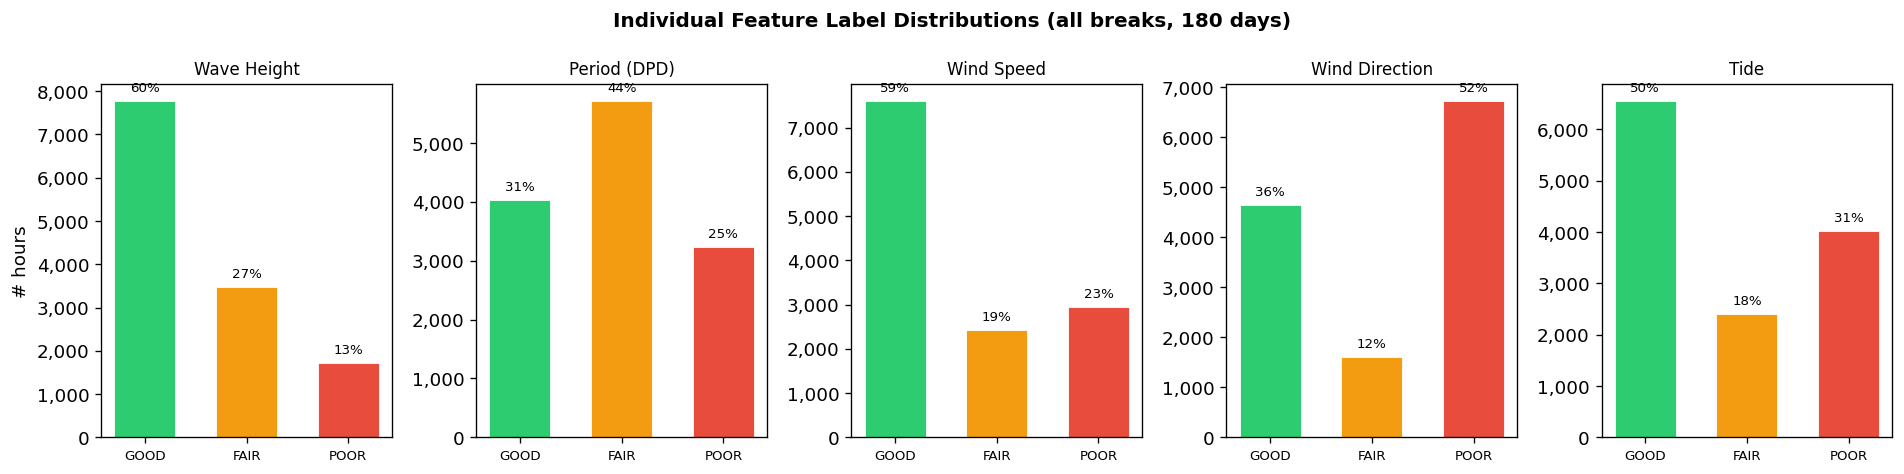

In [30]:
FEAT_META = {
    'wvht_label':        'Wave Height',
    'dpd_label':         'Period (DPD)',
    'wind_speed_label':  'Wind Speed',
    'wind_dir_label':    'Wind Direction',
    'tide_label':        'Tide',
}

fig, axes = plt.subplots(1, len(FEAT_META), figsize=(16, 4), sharey=False)

for ax, (col, title) in zip(axes, FEAT_META.items()):
    counts = df[col].value_counts().reindex(RATINGS, fill_value=0)
    pct    = (counts / counts.sum() * 100).round(1)
    bars   = ax.bar(counts.index, counts.values,
                    color=[COLORS[r] for r in counts.index],
                    edgecolor='white', linewidth=0.5, width=0.6)
    for bar, p in zip(bars, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + counts.max() * 0.02,
                f'{p:.0f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('# hours' if ax == axes[0] else '')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Individual Feature Label Distributions (all breaks, 180 days)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Overall POOR / FAIR / GOOD distribution

This is the target label the model will learn to predict — the overall session rating derived from combining all five feature scores.

**What to look for:**
- How rare is GOOD? GOOD sessions require multiple features aligning at once, so they should be significantly less common than FAIR or POOR
- The balance between FAIR and POOR tells us how often SD surf is at least rideable vs completely bad
- This distribution will shift when real Surfline labels replace the synthetic ones — expect the overall shape to be similar but the exact splits to differ

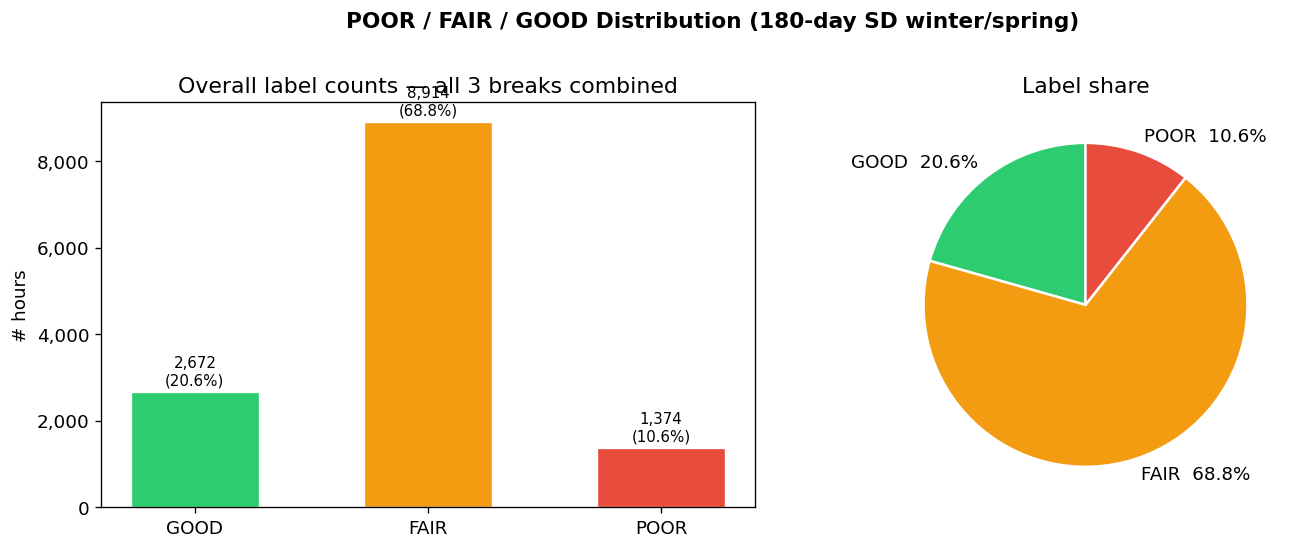

rating
GOOD    20.6
FAIR    68.8
POOR    10.6


In [31]:
overall     = df['rating'].value_counts().reindex(RATINGS, fill_value=0)
overall_pct = (overall / overall.sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(
    overall.index, overall.values,
    color=[COLORS[r] for r in overall.index],
    edgecolor='white', linewidth=0.8, width=0.55
)
for bar, cnt, pct in zip(bars, overall.values, overall_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + overall.max() * 0.01,
                 f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('# hours')
axes[0].set_title('Overall label counts — all 3 breaks combined')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(
    overall.values,
    labels=[f'{r}  {p}%' for r, p in zip(overall.index, overall_pct.values)],
    colors=[COLORS[r] for r in overall.index],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Label share')

plt.suptitle('POOR / FAIR / GOOD Distribution (180-day SD winter/spring)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print(overall_pct.rename('share %').to_string())

## 5. Class imbalance

Class imbalance is when one label appears far more often than another. This is a critical issue for machine learning because a model can cheat by always predicting the majority class and still look accurate.

For example: if 70% of sessions are FAIR, a model that just predicts FAIR every time hits 70% accuracy while being completely useless. **Accuracy is therefore the wrong metric here.** We use F1-macro instead, which forces the model to perform well on all three classes.

**What to look for:**
- An imbalance ratio above 3:1 warrants action
- Above 10:1 means the minority class needs special handling (oversampling or class weighting)
- The recommended fix is `class_weight='balanced'` in sklearn, which automatically upweights minority classes during training

Majority class : FAIR  (8,914 hrs, 68.8%)
Minority class : POOR  (1,374 hrs, 10.6%)
Imbalance ratio: 6.5:1

Verdict: MODERATE — use class_weight="balanced" and stratified CV folds


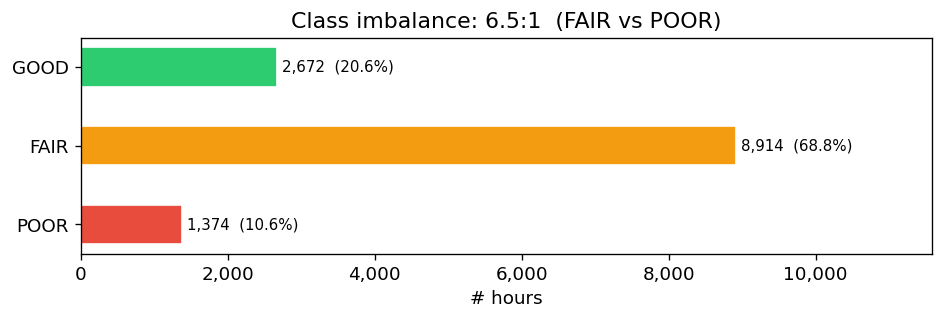

In [32]:
majority = overall.idxmax()
minority = overall.idxmin()
ratio    = overall.max() / overall.min()

print(f'Majority class : {majority}  ({overall[majority]:,} hrs, {overall_pct[majority]}%)')
print(f'Minority class : {minority}  ({overall[minority]:,} hrs, {overall_pct[minority]}%)')
print(f'Imbalance ratio: {ratio:.1f}:1')
print()

if ratio > 10:
    verdict = 'SEVERE — class_weight="balanced" required, report F1-macro not accuracy'
elif ratio > 3:
    verdict = 'MODERATE — use class_weight="balanced" and stratified CV folds'
else:
    verdict = 'MANAGEABLE — standard training OK, still monitor per-class F1'
print(f'Verdict: {verdict}')

fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(RATINGS[::-1], [overall.get(r, 0) for r in RATINGS[::-1]],
        color=[COLORS[r] for r in RATINGS[::-1]], edgecolor='white', height=0.5)
for r in RATINGS:
    cnt = overall.get(r, 0)
    ax.text(cnt + overall.max() * 0.008, RATINGS[::-1].index(r),
            f'{cnt:,}  ({overall_pct[r]}%)', va='center', fontsize=9)
ax.set_xlabel('# hours')
ax.set_title(f'Class imbalance: {ratio:.1f}:1  ({majority} vs {minority})')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlim(0, overall.max() * 1.3)
plt.tight_layout()
plt.show()

## 6. Per-break rating distributions

All three breaks receive the same swell (same buoy data), but each break has a different preferred tide window and slightly different wind exposure. This means the same hour can rate differently at Blacks Beach vs La Jolla Shores vs PB Point.

**What to look for:**
- If all three breaks show nearly identical distributions, the overall rating is driven by swell and wind alone and the break identity does not matter much
- If the distributions differ meaningfully, it validates that `break_id` should be a feature in the model — or better, that we should train a separate model per break
- The most interesting comparison is the GOOD column: which break gets more GOOD hours and why?

The heatmap on the right shows raw hour counts, useful for spotting whether differences are real or just noise from small sample sizes.

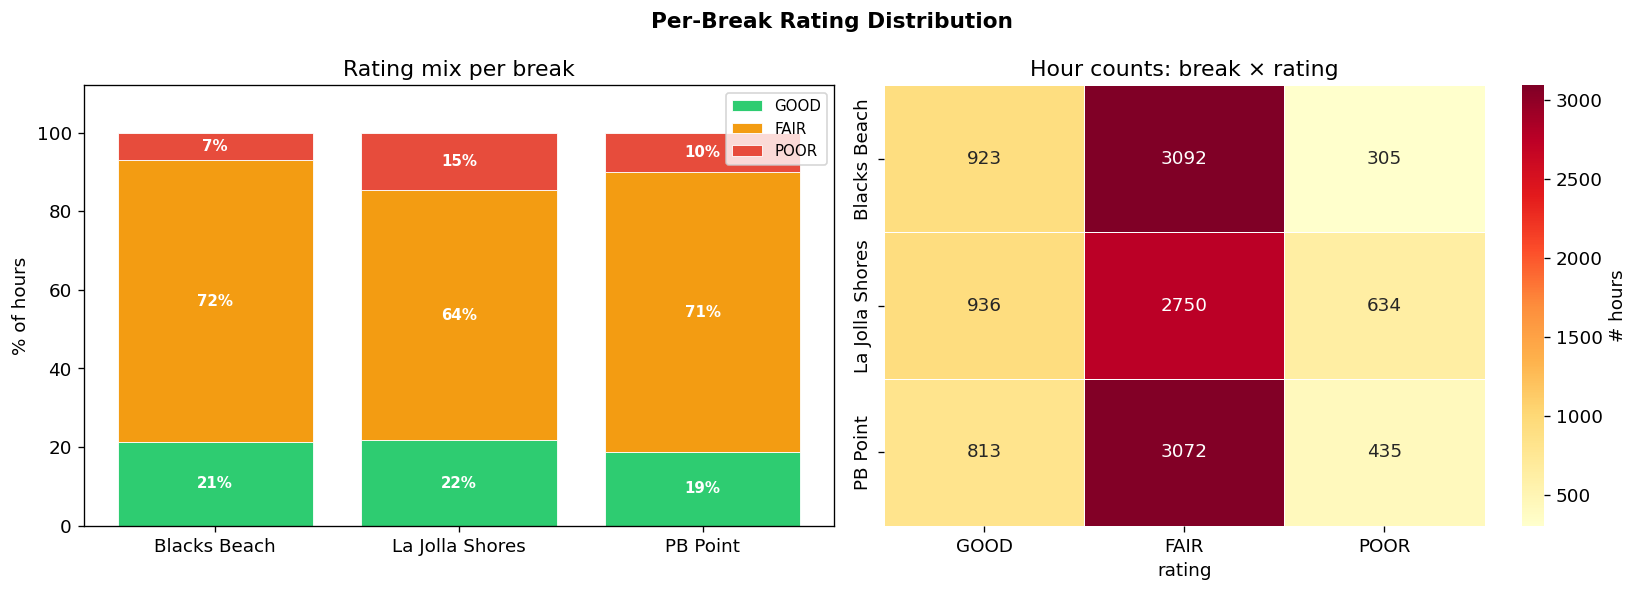

Per-break % breakdown:
rating           GOOD  FAIR  POOR
break                            
Blacks Beach     21.4  71.6   7.1
La Jolla Shores  21.7  63.7  14.7
PB Point         18.8  71.1  10.1


In [33]:
per_break = (
    df.groupby(['break', 'rating']).size()
    .unstack(fill_value=0)
    .reindex(columns=RATINGS, fill_value=0)
)
per_break_pct = per_break.div(per_break.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottom  = np.zeros(len(per_break_pct))
xlabels = [BREAK_LABELS[b] for b in per_break_pct.index]
for r in RATINGS:
    vals = per_break_pct[r].values
    axes[0].bar(xlabels, vals, bottom=bottom, color=COLORS[r],
                label=r, edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            axes[0].text(i, b + v/2, f'{v:.0f}%',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottom += vals
axes[0].set_ylabel('% of hours')
axes[0].set_title('Rating mix per break')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 112)

sns.heatmap(
    per_break.rename(index=BREAK_LABELS),
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': '# hours'}
)
axes[1].set_title('Hour counts: break × rating')
axes[1].set_ylabel('')

plt.suptitle('Per-Break Rating Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Per-break % breakdown:')
print(per_break_pct.rename(index=BREAK_LABELS).round(1).to_string())

## 7. Rating by hour of day

San Diego has one of the most predictable daily wind patterns in the world. The land heats up during the day and pulls cool ocean air onshore — this is the sea breeze. It starts building around 10am and peaks mid-afternoon. At dawn the air is still, and wind is often light and easterly (offshore).

This means **time of day is one of the strongest features we can give the model.** A session at 7am and a session at 2pm can have identical swell and tide readings but completely different wind — and therefore a completely different rating.

**What to look for:**
- GOOD hours should cluster in the shaded green dawn window (roughly 05h–10h Pacific)
- POOR should dominate the shaded red afternoon window (12h–19h)
- If the pattern is flat (GOOD spread evenly across all hours), the diurnal wind signal is not present in the data and we should investigate why
- The bottom chart shows the raw count of rideable hours (GOOD + FAIR) by hour — the dawn peak should be visible

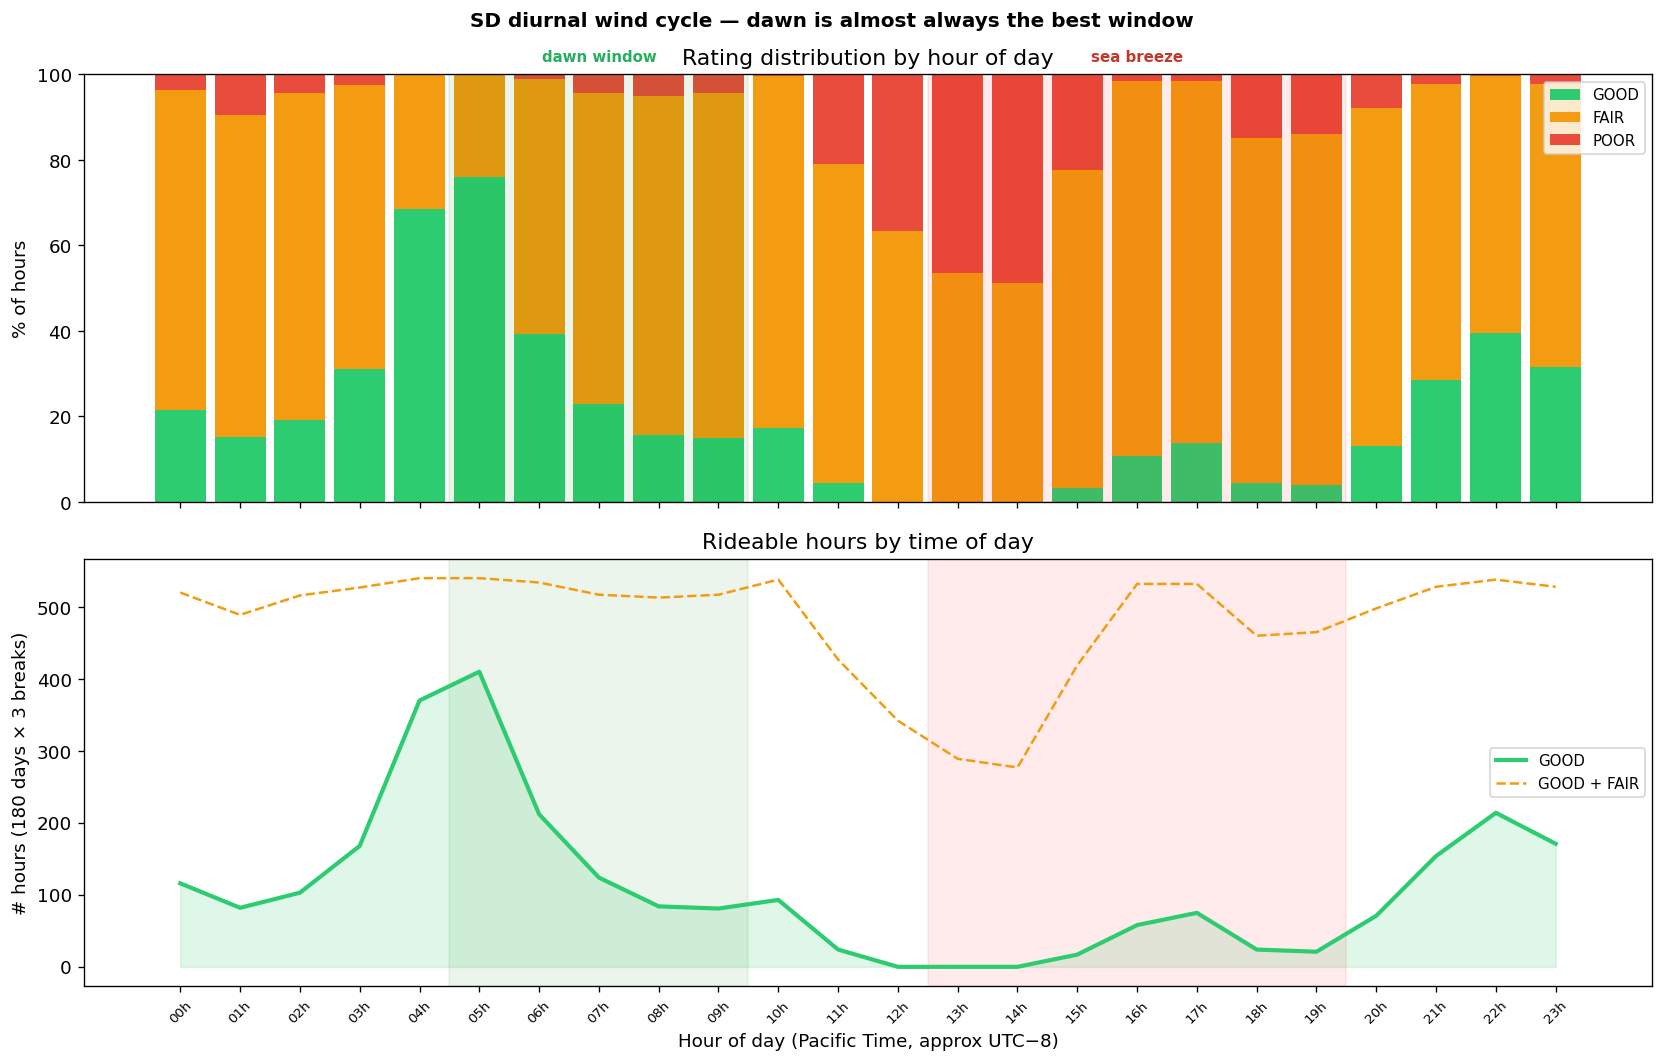

Peak GOOD hour: 05h Pacific


In [34]:
hourly = (
    df.groupby(['pacific_hour', 'rating']).size()
    .unstack(fill_value=0)
    .reindex(columns=RATINGS, fill_value=0)
)
hourly_pct = hourly.div(hourly.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

bottom = np.zeros(len(hourly_pct))
for r in RATINGS:
    vals = hourly_pct[r].values
    axes[0].bar(hourly_pct.index, vals, bottom=bottom,
                color=COLORS[r], label=r, width=0.85)
    bottom += vals
axes[0].axvspan(4.5,  9.5,  alpha=0.08, color='green')
axes[0].axvspan(12.5, 19.5, alpha=0.08, color='red')
axes[0].text(7,  103, 'dawn window', ha='center', color='#27ae60', fontsize=9, fontweight='bold')
axes[0].text(16, 103, 'sea breeze',  ha='center', color='#c0392b', fontsize=9, fontweight='bold')
axes[0].set_ylabel('% of hours')
axes[0].set_title('Rating distribution by hour of day')
axes[0].legend(loc='upper right', fontsize=9)

good_series = hourly.get('GOOD', pd.Series(0, index=hourly.index))
good_hrs    = good_series + hourly.get('FAIR', pd.Series(0, index=hourly.index))
axes[1].plot(hourly.index, good_series, color='#2ecc71', linewidth=2.5, label='GOOD')
axes[1].fill_between(hourly.index, good_series, alpha=0.15, color='#2ecc71')
axes[1].plot(hourly.index, good_hrs, color='#f39c12', linewidth=1.5, linestyle='--', label='GOOD + FAIR')
axes[1].axvspan(4.5,  9.5,  alpha=0.08, color='green')
axes[1].axvspan(12.5, 19.5, alpha=0.08, color='red')
axes[1].set_ylabel('# hours (180 days × 3 breaks)')
axes[1].set_title('Rideable hours by time of day')
axes[1].legend(fontsize=9)
axes[1].set_xticks(range(24))
axes[1].set_xticklabels([f'{h:02d}h' for h in range(24)], rotation=45, fontsize=8)
axes[1].set_xlabel('Hour of day (Pacific Time, approx UTC−8)')

plt.suptitle("SD diurnal wind cycle — dawn is almost always the best window", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

peak = int(good_series.idxmax())
print(f'Peak GOOD hour: {peak:02d}h Pacific')

## 8. Pairwise break agreement

At any given hour, do Blacks Beach, La Jolla Shores, and PB Point all receive the same overall rating? Since they share the same swell input, any disagreement between breaks is entirely caused by differences in wind direction exposure and tide preference.

**What to look for:**
- High agreement (close to 100%) means the breaks are essentially interchangeable — a single model could cover all three
- Low agreement means the breaks behave independently and break-specific models or features will improve accuracy
- The diagonal is always 100% (a break always agrees with itself)
- An off-diagonal value of 70% means those two breaks get the same rating 70% of the time and disagree 30% of the time

All 3 breaks same rating : 63.9%
At least one break differs: 36.1%


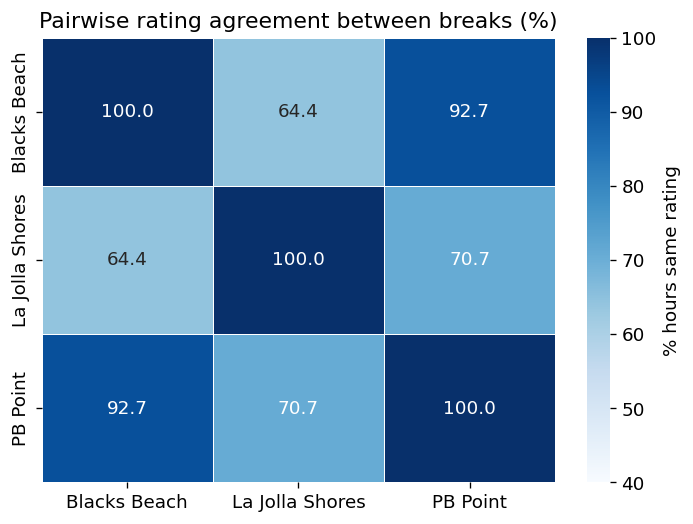

In [35]:
pivot = (
    df.pivot_table(index='hour_utc', columns='break', values='rating', aggfunc='first')
    [BREAKS].dropna()
)

agree_matrix  = pd.DataFrame(index=BREAKS, columns=BREAKS, dtype=float)
for a in BREAKS:
    for b in BREAKS:
        agree_matrix.loc[a, b] = (pivot[a] == pivot[b]).mean() * 100

all_agree_pct = pivot.apply(lambda r: r.nunique() == 1, axis=1).mean() * 100
print(f'All 3 breaks same rating : {all_agree_pct:.1f}%')
print(f'At least one break differs: {100 - all_agree_pct:.1f}%')

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    agree_matrix.rename(index=BREAK_LABELS, columns=BREAK_LABELS).astype(float),
    annot=True, fmt='.1f', cmap='Blues', vmin=40, vmax=100,
    linewidths=0.5, ax=ax, cbar_kws={'label': '% hours same rating'}
)
ax.set_title('Pairwise rating agreement between breaks (%)')
plt.tight_layout()
plt.show()

## 9. Key findings

Summary of everything above for the mentor writeup. Each finding maps directly to a modeling decision.

In [36]:
print('LABEL ANALYSIS — KEY FINDINGS')
print('=' * 50)

print('\n1. OVERALL DISTRIBUTION')
for r in RATINGS:
    print(f'   {r:>5s}: {overall[r]:>7,} hrs  ({overall_pct[r]:.1f}%)')

print(f'\n2. CLASS IMBALANCE: {ratio:.1f}:1')
print(f'   {verdict}')

print('\n3. PER-BREAK')
for brk in BREAKS:
    row   = per_break_pct.loc[brk]
    parts = '  '.join(f'{r}: {row[r]:.0f}%' for r in RATINGS)
    print(f'   {BREAK_LABELS[brk]:20s}  {parts}')

spread        = per_break_pct.max() - per_break_pct.min()
most_variable = spread.idxmax()
print(f'\n   Most variable label across breaks: {most_variable} ({spread[most_variable]:.1f}pp spread)')

print(f'\n4. INTER-BREAK AGREEMENT: {all_agree_pct:.1f}% of hours all three breaks get the same rating')
print(f'   {100 - all_agree_pct:.1f}% diverge → break_id is a meaningful feature')

print(f'\n5. TIME OF DAY: peak GOOD hour is {peak:02d}h Pacific')
print('   Dawn window (05h–10h) concentrates the majority of GOOD sessions')
print('   → hour_of_day (or sin/cos encoding) must be included in the feature set')

LABEL ANALYSIS — KEY FINDINGS

1. OVERALL DISTRIBUTION
    GOOD:   2,672 hrs  (20.6%)
    FAIR:   8,914 hrs  (68.8%)
    POOR:   1,374 hrs  (10.6%)

2. CLASS IMBALANCE: 6.5:1
   MODERATE — use class_weight="balanced" and stratified CV folds

3. PER-BREAK
   Blacks Beach          GOOD: 21%  FAIR: 72%  POOR: 7%
   La Jolla Shores       GOOD: 22%  FAIR: 64%  POOR: 15%
   PB Point              GOOD: 19%  FAIR: 71%  POOR: 10%

   Most variable label across breaks: FAIR (7.9pp spread)

4. INTER-BREAK AGREEMENT: 63.9% of hours all three breaks get the same rating
   36.1% diverge → break_id is a meaningful feature

5. TIME OF DAY: peak GOOD hour is 05h Pacific
   Dawn window (05h–10h) concentrates the majority of GOOD sessions
   → hour_of_day (or sin/cos encoding) must be included in the feature set


---

## 10. Alternative approach: direct scoring (no per-feature labels)

Everything above uses **per-feature labeling** — each feature (wave height, period, wind, tide) is rated independently and the overall POOR/FAIR/GOOD comes from averaging those five votes.

This section shows what happens if we **skip the intermediate labels entirely** and go straight from raw numbers to one overall rating through a single decision function. This is how the existing `etl/score_surf.py` proxy scorer works.

### The difference

| | Per-feature labeling | Direct scoring |
|---|---|---|
| **Intermediate step** | Yes — each feature gets its own POOR/FAIR/GOOD | No — raw values go straight to overall |
| **Model sees** | 5 label columns (categorical) | Raw numeric values |
| **GOOD requires** | Enough features scoring high on average | All conditions simultaneously met |
| **A bad tide with great swell…** | Can still reach FAIR overall | Gets knocked to POOR or FAIR by hard rules |
| **Best use** | Feature engineering for the classifier | Quick human-readable heuristic |

The direct scorer uses the same domain thresholds, but they all fire at once. If any single condition is bad enough, the outcome is POOR — there is no averaging across features to soften a weak factor.

> **Note:** The per-feature approach is what we will use for model training. The direct scorer is here as a sanity check and for comparison.

### Direct scorer

The function below evaluates all conditions at once:
- **GOOD**: wave height in the ideal range AND long-period groundswell AND wind is light AND offshore AND tide is in the preferred window — everything must align
- **POOR**: any single disqualifying condition (flat, too big, pure wind chop, strong onshore wind) — one bad factor is enough
- **FAIR**: everything else — conditions exist but not everything is dialed in

In [37]:
def rate_direct(wvht_m, dpd, wind_mph, wind_dir, tide_ft, brk):
    """
    Rate surf quality directly from raw values — no intermediate feature labels.

    GOOD  : ideal range on every dimension simultaneously
    POOR  : any single disqualifying condition
    FAIR  : surfable but something is off
    """
    ft    = wvht_m * 3.281
    delta = abs((wind_dir - 90 + 180) % 360 - 180)   # angular distance from East
    offshore  = delta <= 45
    tlo, thi  = TIDE_WIN[brk]
    good_tide = tlo <= tide_ft <= thi
    long_swell = dpd > 18
    wind_limit = 18 if long_swell else 15

    # GOOD: every condition in the ideal zone
    if (3.3 <= ft <= 8.2
            and dpd >= 12
            and wind_mph <= wind_limit
            and offshore
            and good_tide):
        return 'GOOD'

    # POOR: any hard disqualifier
    if ft < 1.6 or ft > 9.8:          return 'POOR'   # flat or too big
    if dpd < 8:                        return 'POOR'   # pure wind chop
    if not offshore and wind_mph > 15: return 'POOR'   # strong onshore

    # FAIR: surfable but not ideal
    return 'FAIR'


# Apply to the same synthetic dataset (base DataFrame, same seed=42)
dir_frames = []
for brk, offset in offsets.items():
    d = base.copy()
    d['break']          = brk
    d['wind_dir_break'] = (d['wind_dir'] + offset) % 360
    d['rating_direct']  = d.apply(
        lambda r: rate_direct(r.wvht, r.dpd, r.wind_mph, r.wind_dir_break, r.tide_ft, brk),
        axis=1
    )
    dir_frames.append(d)

df_direct = pd.concat(dir_frames, ignore_index=True)

# Summary distribution
direct_overall     = df_direct['rating_direct'].value_counts().reindex(RATINGS, fill_value=0)
direct_overall_pct = (direct_overall / direct_overall.sum() * 100).round(1)

print('Direct scorer — overall distribution:')
for r in RATINGS:
    print(f'   {r:>5s}: {direct_overall[r]:>7,} hrs  ({direct_overall_pct[r]:.1f}%)')

d_ratio = direct_overall.max() / direct_overall[direct_overall > 0].min()
print(f'\nImbalance ratio: {d_ratio:.1f}:1')

Direct scorer — overall distribution:
    GOOD:     360 hrs  (2.8%)
    FAIR:   7,043 hrs  (54.3%)
    POOR:   5,557 hrs  (42.9%)

Imbalance ratio: 19.6:1


### 10a. Direct scorer — overall distribution and per-break breakdown

Same visualizations as the per-feature approach so the two can be compared side by side.

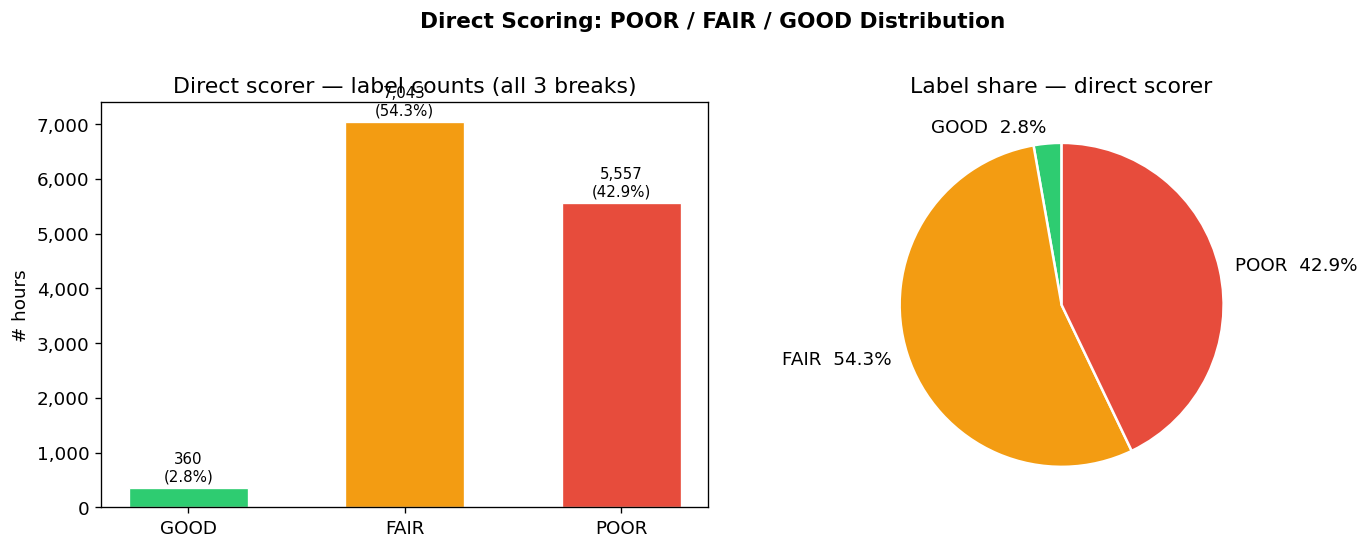

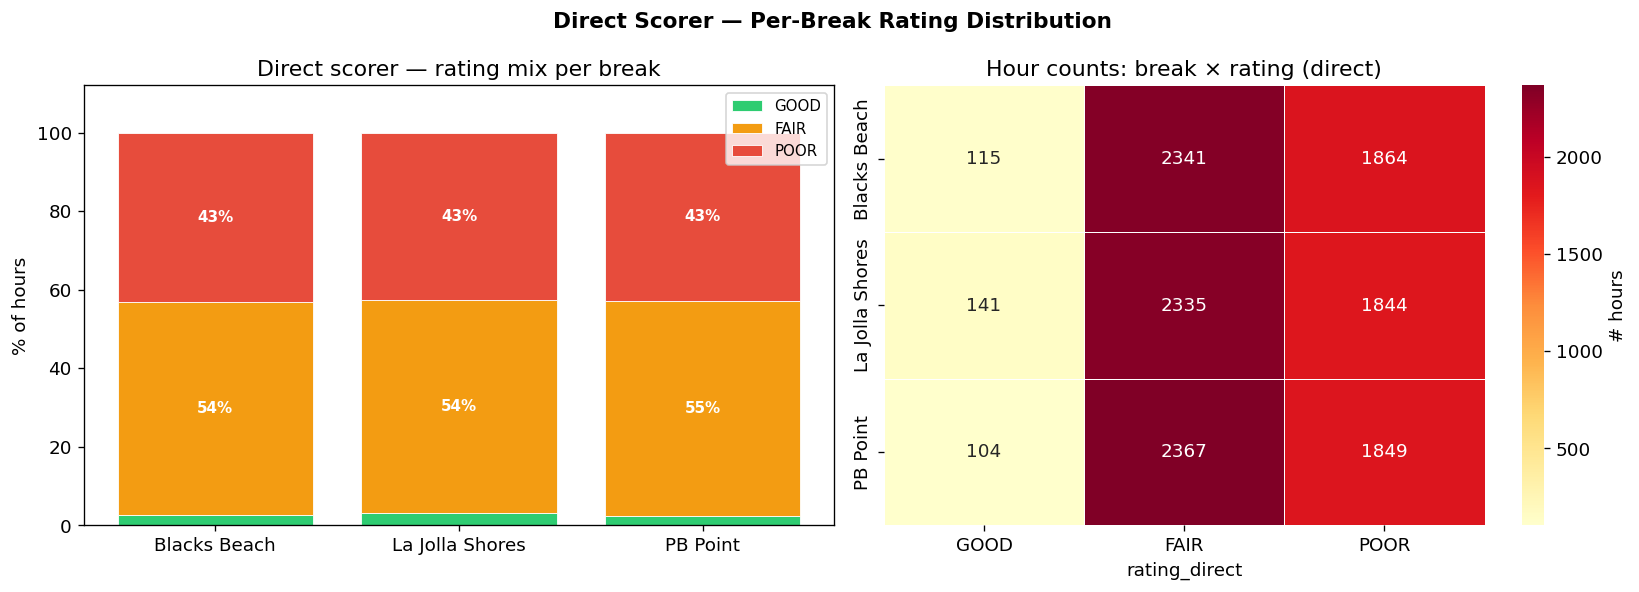

Direct scorer — per-break % breakdown:
rating_direct    GOOD  FAIR  POOR
break                            
Blacks Beach      2.7  54.2  43.1
La Jolla Shores   3.3  54.1  42.7
PB Point          2.4  54.8  42.8


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

bars = axes[0].bar(
    direct_overall.index, direct_overall.values,
    color=[COLORS[r] for r in direct_overall.index],
    edgecolor='white', linewidth=0.8, width=0.55
)
for bar, cnt, pct in zip(bars, direct_overall.values, direct_overall_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + direct_overall.max() * 0.01,
                 f'{cnt:,}\n({pct}%)', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('# hours')
axes[0].set_title('Direct scorer — label counts (all 3 breaks)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

axes[1].pie(
    direct_overall.values,
    labels=[f'{r}  {p}%' for r, p in zip(direct_overall.index, direct_overall_pct.values)],
    colors=[COLORS[r] for r in direct_overall.index],
    startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Label share — direct scorer')

plt.suptitle('Direct Scoring: POOR / FAIR / GOOD Distribution', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Per-break
dir_per_break = (
    df_direct.groupby(['break', 'rating_direct']).size()
    .unstack(fill_value=0)
    .reindex(columns=RATINGS, fill_value=0)
)
dir_per_break_pct = dir_per_break.div(dir_per_break.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bottom  = np.zeros(len(dir_per_break_pct))
xlabels = [BREAK_LABELS[b] for b in dir_per_break_pct.index]
for r in RATINGS:
    vals = dir_per_break_pct[r].values
    axes[0].bar(xlabels, vals, bottom=bottom, color=COLORS[r],
                label=r, edgecolor='white', linewidth=0.5)
    for i, (v, b) in enumerate(zip(vals, bottom)):
        if v > 4:
            axes[0].text(i, b + v/2, f'{v:.0f}%',
                         ha='center', va='center', fontsize=9,
                         color='white', fontweight='bold')
    bottom += vals
axes[0].set_ylabel('% of hours')
axes[0].set_title('Direct scorer — rating mix per break')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_ylim(0, 112)

sns.heatmap(
    dir_per_break.rename(index=BREAK_LABELS),
    annot=True, fmt='d', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': '# hours'}
)
axes[1].set_title('Hour counts: break × rating (direct)')
axes[1].set_ylabel('')

plt.suptitle('Direct Scorer — Per-Break Rating Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Direct scorer — per-break % breakdown:')
print(dir_per_break_pct.rename(index=BREAK_LABELS).round(1).to_string())

### 10b. Head-to-head comparison

How much do the two approaches agree? Where they disagree tells us something important: those are the sessions where a single bad factor is enough to flip the direct scorer to POOR but the per-feature averaging still finds enough good to call it FAIR.

The confusion matrix below shows how each per-feature rating maps to its direct-scoring equivalent for the same session.

Overall agreement between approaches: 51.3%
Disagree on 48.7% of sessions



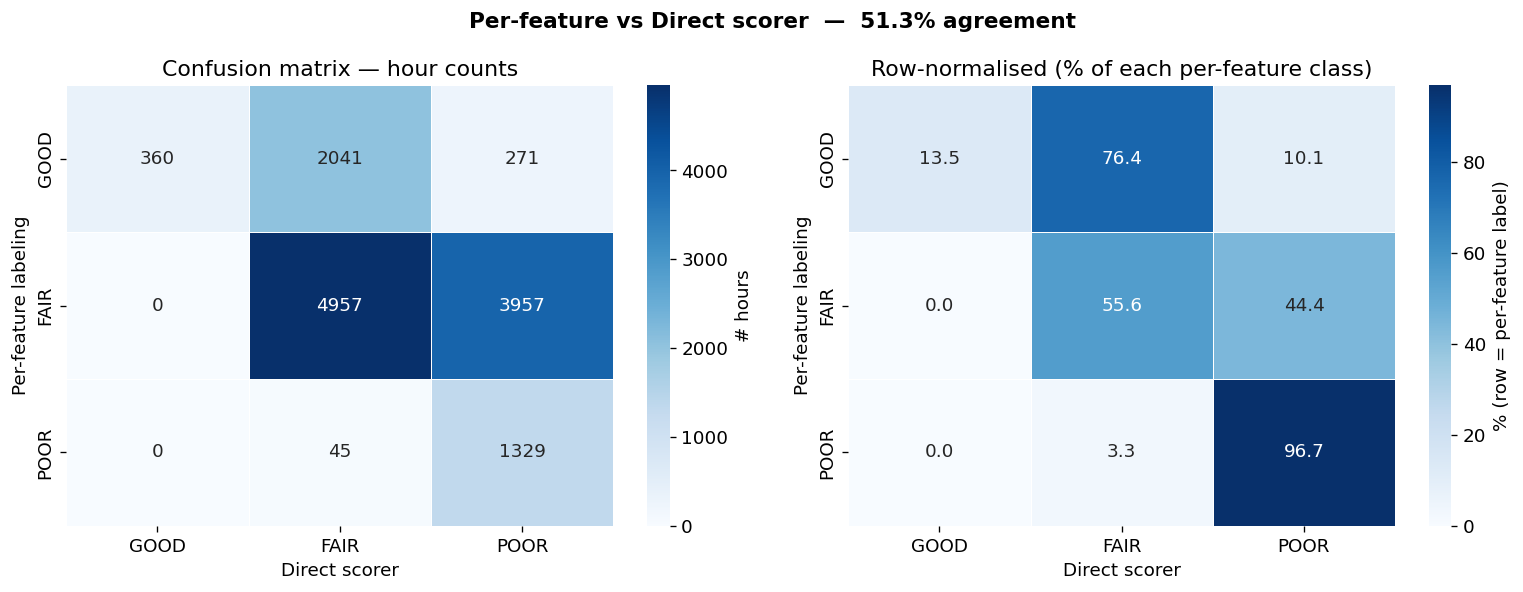

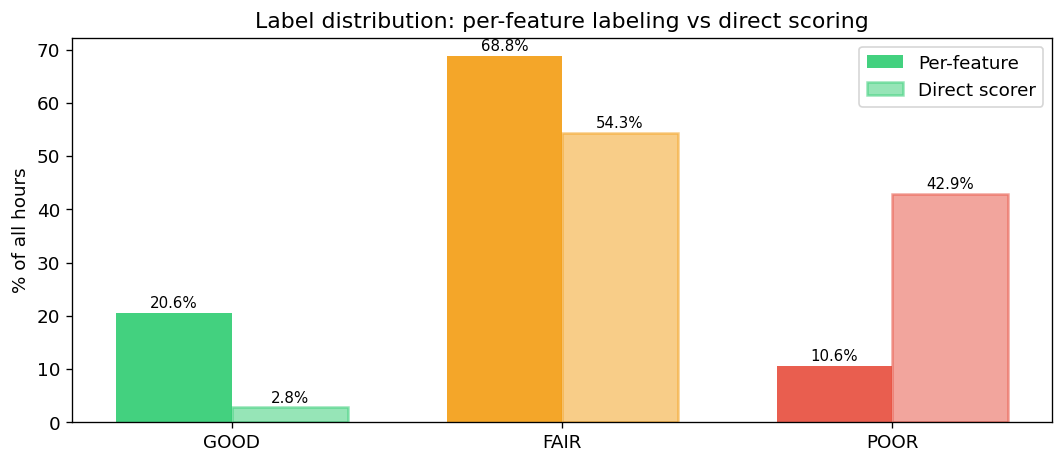

In [39]:
# Merge both ratings on the same rows (same synthetic data, same seed)
compare = df[['hour_utc', 'break', 'rating']].copy()
compare['rating_direct'] = df_direct['rating_direct'].values
agreement = (compare['rating'] == compare['rating_direct']).mean() * 100

print(f'Overall agreement between approaches: {agreement:.1f}%')
print(f'Disagree on {100 - agreement:.1f}% of sessions\n')

# Confusion matrix: rows = per-feature, cols = direct
conf = (
    compare.groupby(['rating', 'rating_direct']).size()
    .unstack(fill_value=0)
    .reindex(index=RATINGS, columns=RATINGS, fill_value=0)
)
conf_pct = conf.div(conf.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(conf, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': '# hours'})
axes[0].set_xlabel('Direct scorer')
axes[0].set_ylabel('Per-feature labeling')
axes[0].set_title('Confusion matrix — hour counts')

# Row-normalised (what % of per-feature GOOD/FAIR/POOR ends up where in direct)
sns.heatmap(conf_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '% (row = per-feature label)'})
axes[1].set_xlabel('Direct scorer')
axes[1].set_ylabel('Per-feature labeling')
axes[1].set_title('Row-normalised (% of each per-feature class)')

plt.suptitle(f'Per-feature vs Direct scorer  —  {agreement:.1f}% agreement', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Side-by-side summary bar chart
fig, ax = plt.subplots(figsize=(9, 4))
x       = np.arange(len(RATINGS))
w       = 0.35
feat_pct   = [overall_pct[r] for r in RATINGS]
direct_pct = [direct_overall_pct[r] for r in RATINGS]

b1 = ax.bar(x - w/2, feat_pct,   w, label='Per-feature',  color=[COLORS[r] for r in RATINGS], alpha=0.9)
b2 = ax.bar(x + w/2, direct_pct, w, label='Direct scorer', color=[COLORS[r] for r in RATINGS], alpha=0.5,
            edgecolor=[COLORS[r] for r in RATINGS], linewidth=1.5)

for bar, v in zip(b1, feat_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
for bar, v in zip(b2, direct_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(RATINGS)
ax.set_ylabel('% of all hours')
ax.set_title('Label distribution: per-feature labeling vs direct scoring')
ax.legend()
plt.tight_layout()
plt.show()

### 10c. Takeaway

Both approaches use the same thresholds and the same data, so they should broadly agree. The key difference shows up on **borderline sessions**:

- The **direct scorer** is strict — all conditions must simultaneously clear the bar for GOOD, and any one dealbreaker flips to POOR
- The **per-feature labeler** is forgiving — a great swell can compensate for a so-so tide and still average out to FAIR

This has a direct modeling implication: the per-feature approach produces more **FAIR** sessions (the recoverable middle ground), while the direct scorer tends to collapse ambiguous cases to POOR. For training a classifier, more FAIR examples that are genuinely representative of marginal conditions is better than fewer, harder-edged labels.

**Bottom line:** use the per-feature label columns as model features + the per-feature overall rating as the target. The direct scorer is a useful sanity check and a good stand-in for rules-based baseline comparison.